<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:42: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:42: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_17/1509065927.py:36: SyntaxWarning: invalid escape sequence '\d'
  ax1[0].annotate('$\dot VO_2max$ =({}) L/min'.format(round(ymax, 2)),
/tmp/ipykernel_17/1509065927.py:42: SyntaxWarning: invalid escape sequence '\d'
  ax1[0].plot(x, y, 'o', label=('$\dot VO_2$'), c='r' )


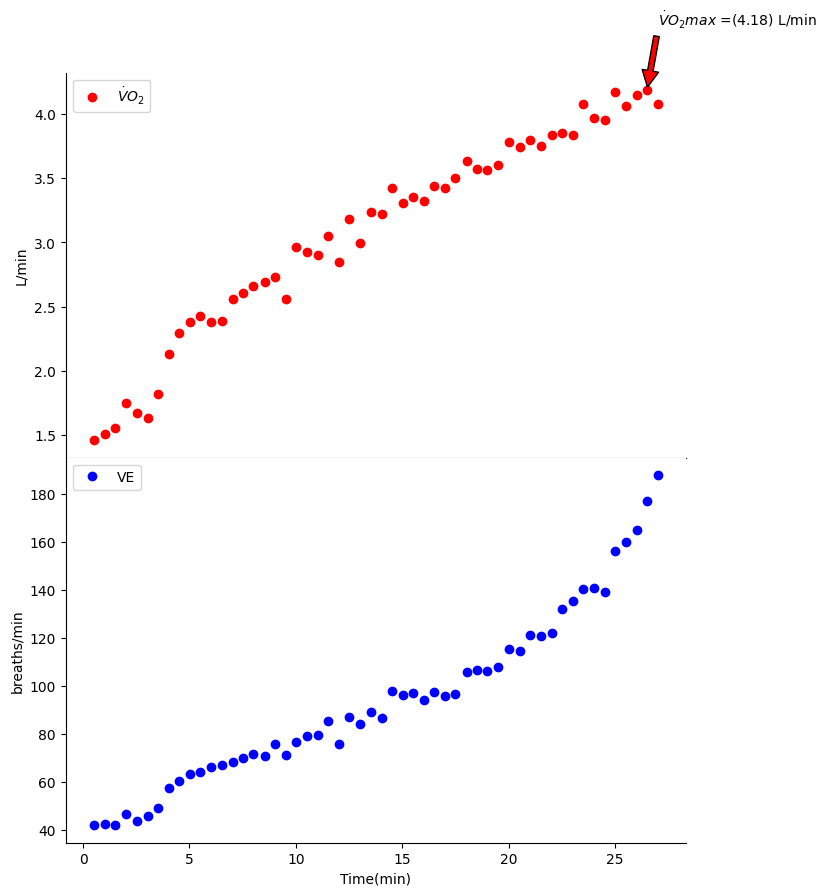

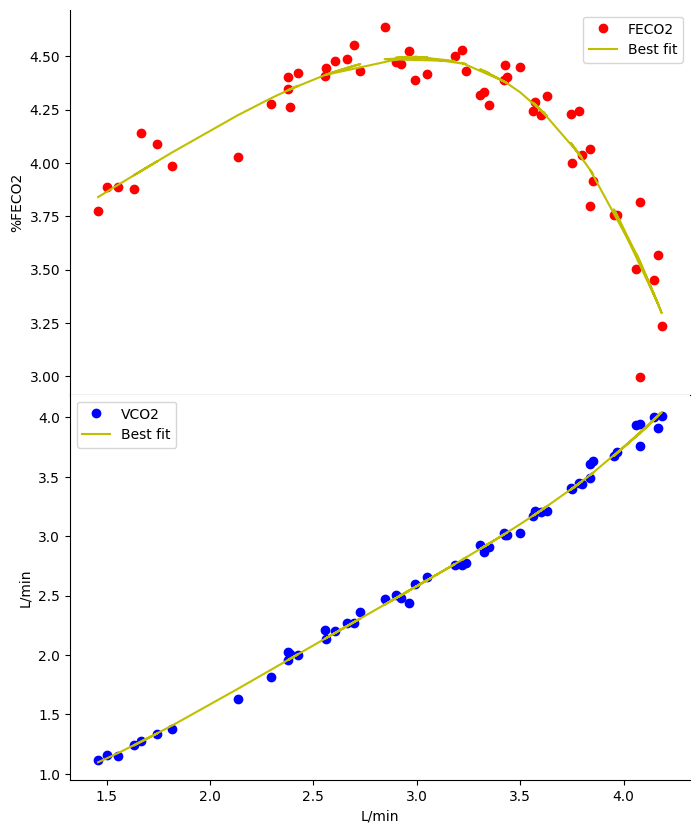

In [1]:
### Now all together in one code block that could run independently...

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Lets read in our file now
df = pd.read_csv('/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1232.csv', header=[0], skiprows=[1,2,3])

# please note that while this is an output file from the parvo-metabolics cart we have
# I have edited this data set and simplied the header file on it

# rename our column headers
df = df.rename(columns={'VE/': 'VE/VO2','VE/.1': 'VE/VCO2'})

# simplify our terms to reduce future typing... 
# it is easier to write plot x, y than plot df['Time'], df['VO2']
x = df['TIME']
y = df['VO2']
y1 = df['VE']

VO2 = df['VO2']
FECO2 = df['FECO2']
VCO2 = df['VCO2']

#Find VO2 max value 
ymax = max(y)

# find the x position of the ymax value or where ymax occurs on the x axis
xmax = x[y.argmax()]

fig1, ax1 = plt.subplots(2, 1, sharex=True, figsize=(8, 10)) # Note I increased the figure size here.

fig1.subplots_adjust(hspace=0) #line separating 2 plots in subplot fig1

ax1[0].annotate('$\dot VO_2max$ =({}) L/min'.format(round(ymax, 2)), 
               xy=(xmax, ymax), xytext=(xmax+.5, ymax+ .5),
               arrowprops=dict(facecolor='red', shrink= 0.05),
                ) #annotate position of VO2max + arrow 

#First plot of first figure 
ax1[0].plot(x, y, 'o', label=('$\dot VO_2$'), c='r' )
# in the line of code below I hide the top and right black bars serrounding the plot for APA format.
ax1[0].spines[['right', 'top']].set_visible(False)
ax1[0].set(ylabel=('L/min'))
ax1[0].legend()
#note all these set features could be added in one line but reading it would be difficult

# Second plot of first figure
ax1[1].plot(x, y1, 'o', label=('VE'), c='b')
ax1[1].spines[['top', 'right']].set_visible(False)
ax1[1].set(ylabel=('breaths/min'))
ax1[1].set(xlabel=('Time(min)'))
ax1[1].legend()

fig2, ax2 = plt.subplots(2, 1, sharex=True, figsize=(8, 10)) # Note fig size increase
fig2.subplots_adjust(hspace=0) #line separating 2 plots in subplot fig2

# First plot of second figure
# Line of best fit for FECO2 vs VO2
polycoef1 = np.polyfit(VO2, FECO2, 4) #quartic polynomial
FECO2_fit = np.polyval(polycoef1, VO2)

ax2[0].plot(VO2, FECO2, 'o', label=('FECO2'), c='r')
ax2[0].plot(VO2, FECO2_fit, '-', label='Best fit', c='y') #line of best fit
ax2[0].spines[['top', 'right']].set_visible(False)
ax2[0].set(ylabel=('%FECO2'))
ax2[0].set(xlabel=('L/min'))
ax2[0].legend()

#Second plot of second figure 
# Line of best fit for VCO2 vs VO2
polycoef2 = np.polyfit(VO2, VCO2, 4) #quartic polynomial
VCO2_fit = np.polyval(polycoef2, VO2)

ax2[1].plot(VO2, VCO2, 'o', label=('VCO2'), c='b')
ax2[1].plot(VO2, VCO2_fit, '-', label='Best fit', c='y') #line of best fit
ax2[1].spines[['top', 'right']].set_visible(False)
ax2[1].set(ylabel=('L/min'))
ax2[1].set(xlabel=('L/min'))
ax2[1].legend()

# save the figure before we show it... or it will be blank
fig1.savefig("VO2-VE-Time.png", dpi=300, bbox_inches = "tight")
fig1.show()

fig2.savefig("FECO2-VCO2-VO2.png", dpi=300, bbox_inches = "tight")
fig2.show()